In [1]:
import shutil
import os

# Get the current directory
current_dir = os.getcwd()

# Loop through all items in the directory
for item in os.listdir(
    current_dir):
    item_path = os.path.join(current_dir, item)
    # Check if the item is a directory
    if os.path.isdir(item_path):
        shutil.rmtree(item_path)  # Remove the folder and its contents

print("All folders removed successfully!")


All folders removed successfully!


**DATA COLLECTION PROCESS**

In [2]:
pip install waybackpy

In [3]:
pip install beautifulsoup4 pandas matplotlib

In [4]:
pip install beautifulsoup4 pandas tabulate

In [5]:
# Imports
import os
import requests
from bs4 import BeautifulSoup
from waybackpy import WaybackMachineCDXServerAPI
from waybackpy.exceptions import WaybackError
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from IPython.display import display
import re
from tabulate import tabulate
import matplotlib.dates as mdates

In [6]:
# Define the target website and archive timestamps (YYYYMMDD)
url = "https://www.airbnb.com"
dates = {
    "2009": "20090503",
    "2013": "20130312",
    "2014": "20141113",
    "2016": "20161201",
    "2020": "20201101",
    "2021": "20210903",
    "2022": "20221215",
    "2024": "20241215",
}

# Define base directories
base_dir = "Airbnb_Website_Archive"
snapshots_dir = os.path.join(base_dir, "Snapshots")
metadata_dir = os.path.join(base_dir, "Metadata")
os.makedirs(snapshots_dir, exist_ok=True)
os.makedirs(metadata_dir, exist_ok=True)

# Metadata file path
metadata_file = os.path.join(metadata_dir, "metadata_summary.txt")

# Function to clean Wayback Machine elements from HTML
def clean_wayback_html(html_content):
    soup = BeautifulSoup(html_content, "html.parser")
    # Remove Wayback Machine-specific elements
    for element in soup.find_all("script", src=lambda x: x and "web-static.archive.org" in x):
        element.decompose()
    for element in soup.find_all("link", href=lambda x: x and "web-static.archive.org" in x):
        element.decompose()
    for element in soup.find_all("meta", content=lambda x: x and "web.archive.org" in x):
        element.decompose()
    for element in soup.find_all("iframe", src=lambda x: x and "web.archive.org" in x):
        element.decompose()
    for element in soup.find_all("div", id="wm-ipp"):
        element.decompose()
    # Extract body content
    body_content = soup.find("body")
    return str(body_content) if body_content else soup.prettify()

# Function to download and clean HTML snapshot with more precise timestamp targeting
def download_wayback_html(year, date):
    year_folder = os.path.join(snapshots_dir, year)
    os.makedirs(year_folder, exist_ok=True)
    try:
        # Create a direct Wayback Machine URL with the exact timestamp
        # Format: https://web.archive.org/web/[timestamp]/[original URL]
        archive_url = f"https://web.archive.org/web/{date}000000/{url}"

        print(f"[{year}] Trying archive URL: {archive_url}")
        response = requests.get(archive_url, allow_redirects=True)

        # Check if we got redirected to a different timestamp
        if response.url != archive_url and "web.archive.org" in response.url:
            print(f"[{year}] Redirected to: {response.url}")

        status = "Success" if response.status_code == 200 else "Failed"

        if response.status_code == 200 and response.text.strip():
            original_html_path = os.path.join(year_folder, f"{year}_airbnb_original.html")
            with open(original_html_path, "w", encoding="utf-8") as file:
                file.write(response.text)

            # Clean the HTML
            cleaned_html = clean_wayback_html(response.text)
            if cleaned_html.strip():  # Ensure cleaned content is not empty before saving
                cleaned_html_path = os.path.join(year_folder, f"{year}_airbnb_cleaned.html")
                with open(cleaned_html_path, "w", encoding="utf-8") as file:
                    file.write(cleaned_html)
                print(f"[{year}] Downloaded and cleaned HTML successfully.")
            else:
                cleaned_html_path = "Not Saved (Empty Content)"
                print(f"[{year}] Cleaned HTML is empty. Skipping save.")
        else:
            # If direct URL fails, try the CDX API as a fallback
            print(f"[{year}] Direct URL failed. Trying CDX API...")
            cdx_api = WaybackMachineCDXServerAPI(url)

            # Find snapshots within a window (same month)
            month_start = f"{date[:6]}01000000"
            month_end = f"{date[:6]}31235959"

            try:
                snapshots = list(cdx_api.search(from_date=month_start, to_date=month_end))

                if snapshots:
                    # Sort snapshots by how close they are to the target date
                    snapshots.sort(key=lambda s: abs(int(s.timestamp[:8]) - int(date)))
                    snapshot = snapshots[0]  # Get the closest one
                    archive_url = snapshot.archive_url

                    print(f"[{year}] Found alternative snapshot: {archive_url}")
                    response = requests.get(archive_url)

                    if response.status_code == 200 and response.text.strip():
                        original_html_path = os.path.join(year_folder, f"{year}_airbnb_original.html")
                        with open(original_html_path, "w", encoding="utf-8") as file:
                            file.write(response.text)

                        # Clean the HTML
                        cleaned_html = clean_wayback_html(response.text)
                        if cleaned_html.strip():
                            cleaned_html_path = os.path.join(year_folder, f"{year}_airbnb_cleaned.html")
                            with open(cleaned_html_path, "w", encoding="utf-8") as file:
                                file.write(cleaned_html)
                            print(f"[{year}] Downloaded and cleaned HTML successfully.")
                        else:
                            cleaned_html_path = "Not Saved (Empty Content)"
                            print(f"[{year}] Cleaned HTML is empty. Skipping save.")
                    else:
                        original_html_path = "Not Saved (Download Failed)"
                        cleaned_html_path = "Not Saved"
                else:
                    print(f"[{year}] No snapshots found for the specified month.")
                    original_html_path = "Not Saved (No Snapshots)"
                    cleaned_html_path = "Not Saved"
            except Exception as e:
                print(f"[{year}] CDX API error: {e}")
                original_html_path = "Not Saved (API Error)"
                cleaned_html_path = "Not Saved"

        # Log metadata
        with open(metadata_file, "a", encoding="utf-8") as meta:
            meta.write(
                f"Year: {year}, Date: {date}, Snapshot URL: {archive_url}, "
                f"Original File: {original_html_path}, Cleaned File: {cleaned_html_path}, Status: {status}\n"
            )
    except WaybackError as e:
        print(f"[{year}] Wayback Machine error: {e}")
        with open(metadata_file, "a", encoding="utf-8") as meta:
            meta.write(f"Year: {year}, Date: {date}, Snapshot URL: None, Status: WaybackError: {e}\n")
    except Exception as e:
        print(f"[{year}] Unexpected error: {e}")
        with open(metadata_file, "a", encoding="utf-8") as meta:
            meta.write(f"Year: {year}, Date: {date}, Snapshot URL: None, Status: Unexpected Error: {e}\n")

# Clear previous metadata file
open(metadata_file, "w").close()

# Process all snapshots
for year, date in dates.items():
    download_wayback_html(year, date)

print(f"\nMetadata summary saved to: {metadata_file}")

[2009] Trying archive URL: https://web.archive.org/web/20090503000000/https://www.airbnb.com
[2009] Redirected to: https://web.archive.org/web/20090503105255/http://www.airbnb.com/
[2009] Downloaded and cleaned HTML successfully.
[2013] Trying archive URL: https://web.archive.org/web/20130312000000/https://www.airbnb.com
[2013] Redirected to: https://web.archive.org/web/20130312021744/https://www.airbnb.com/
[2013] Downloaded and cleaned HTML successfully.
[2014] Trying archive URL: https://web.archive.org/web/20141113000000/https://www.airbnb.com
[2014] Redirected to: https://web.archive.org/web/20141113030829/https://www.airbnb.com/
[2014] Downloaded and cleaned HTML successfully.
[2016] Trying archive URL: https://web.archive.org/web/20161201000000/https://www.airbnb.com
[2016] Redirected to: https://web.archive.org/web/20161201074254/https://www.airbnb.com/
[2016] Downloaded and cleaned HTML successfully.
[2020] Trying archive URL: https://web.archive.org/web/20201101000000/https:/

This script retrieves historical snapshots of Airbnb's homepage using the Wayback Machine API. For each specified date, it:

+ Attempts to fetch the archived webpage via a direct Wayback Machine URL.
+ If the direct fetch fails, it searches for the closest available snapshot using the CDX API.
+ Downloads the HTML content and removes Wayback Machine-specific elements using BeautifulSoup.
+ Saves both the original and cleaned HTML versions in organized directories.
+ Logs metadata, including the snapshot URL, file paths, and status, for reproducibility.



**ANALYSIS PROCESS**

**Airbnb’s HTML DOCTYPE and features change over time**

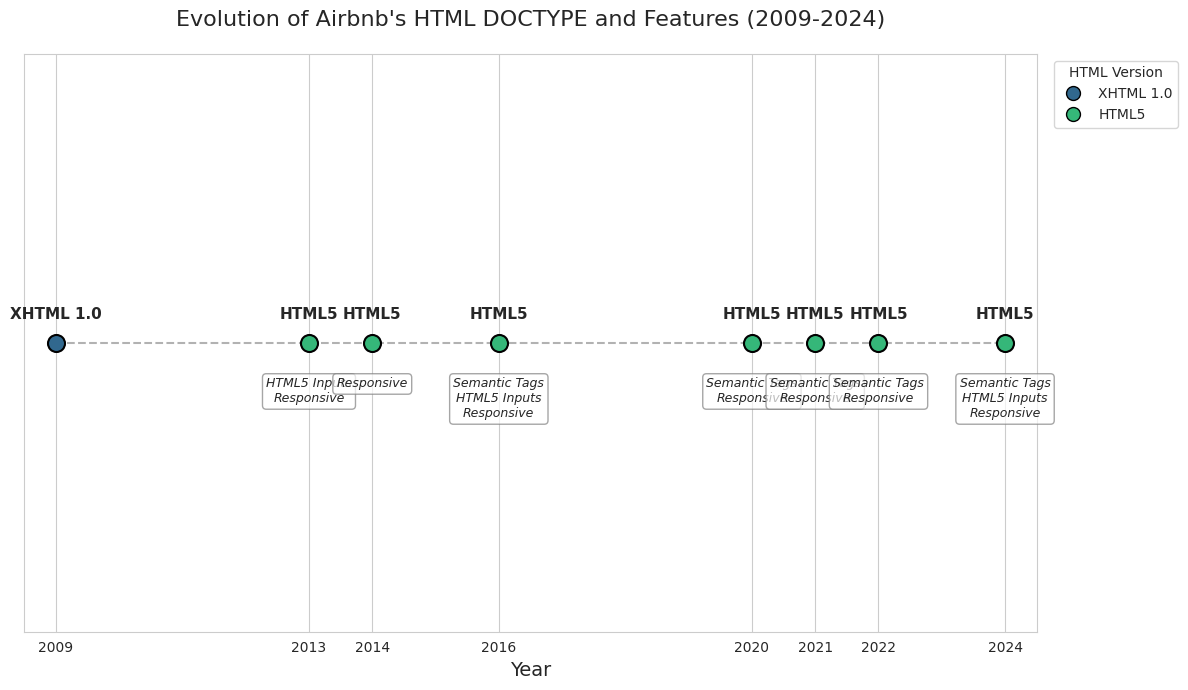

In [7]:
# Define base directories
BASE_DIR = "Airbnb_Website_Archive"
SNAPSHOTS_DIR = os.path.join(BASE_DIR, "Snapshots")
YEARS = ["2009", "2013", "2014", "2016", "2020", "2021", "2022", "2024"]

def analyze_doctype(file_path):
    """Analyze and extract DOCTYPE information from HTML files"""
    try:
        with open(file_path, "r", encoding="utf-8", errors="ignore") as file:
            content = file.read()

            # Extract DOCTYPE
            doctype_match = re.search(r'<!DOCTYPE[^>]*>', content, re.IGNORECASE)
            doctype = doctype_match.group(0) if doctype_match else "None Found"

            # Determine HTML version based on DOCTYPE
            html_version = "Unknown"

            if "HTML 4.01" in doctype:
                html_version = "HTML 4.01"
            elif "XHTML 1.0" in doctype:
                html_version = "XHTML 1.0"
            elif "XHTML 1.1" in doctype:
                html_version = "XHTML 1.1"
            elif "html" in doctype.lower() and not any(x in doctype for x in ["HTML 4", "XHTML"]):
                html_version = "HTML5"

            # Check meta tags for additional information
            soup = BeautifulSoup(content, "html.parser")

            # Check for HTML5 features
            has_semantic_elements = any(soup.find_all(tag) for tag in ['header', 'footer', 'nav', 'section', 'article', 'aside'])
            has_html5_input_types = any(soup.find_all('input', {'type': type_}) for type_ in ['email', 'tel', 'url', 'search', 'range', 'date'])

            if html_version == "Unknown" and (has_semantic_elements or has_html5_input_types):
                html_version = "HTML5 (implied)"

            # Check for additional meta information
            charset_meta = soup.find('meta', {'charset': True})
            charset = charset_meta['charset'] if charset_meta else None

            content_type_meta = soup.find('meta', {'http-equiv': 'Content-Type'})
            content_type = content_type_meta['content'] if content_type_meta else None

            # Check for mobile/responsive meta tags
            viewport_meta = soup.find('meta', {'name': 'viewport'})
            has_viewport = bool(viewport_meta)

            return {
                'doctype': doctype,
                'html_version': html_version,
                'charset': charset,
                'content_type': content_type,
                'has_semantic_elements': has_semantic_elements,
                'has_html5_input_types': has_html5_input_types,
                'has_viewport_meta': has_viewport,
            }
    except Exception as e:
        print(f"Error analyzing DOCTYPE in {file_path}: {e}")
        return {
            'doctype': "Error",
            'html_version': "Error",
            'charset': None,
            'content_type': None,
            'has_semantic_elements': False,
            'has_html5_input_types': False,
            'has_viewport_meta': False,
        }

def display_doctype_evolution_chart(base_dir="Airbnb_Website_Archive"):
    """Display a chart showing the evolution of DOCTYPE declarations over time"""
    results = []

    for year in YEARS:
        file_path = f"{base_dir}/Snapshots/{year}/{year}_airbnb_original.html"
        try:
            doctype_info = analyze_doctype(file_path)
            doctype_info['year'] = int(year)
            results.append(doctype_info)
        except FileNotFoundError:
            print(f"Year {year}: Original HTML file not found at {file_path}")

    # Convert to DataFrame
    df = pd.DataFrame(results)

    # Create the visualization
    plt.figure(figsize=(12, 7))

    # Set up the style
    sns.set_style("whitegrid")

    # Create a categorical color palette
    version_categories = df['html_version'].unique()
    colors = sns.color_palette("viridis", len(version_categories))
    color_map = dict(zip(version_categories, colors))

    # Plot the HTML version evolution
    for i, row in df.iterrows():
        plt.scatter(row['year'], 0, s=150, color=color_map[row['html_version']],
                   marker='o', edgecolor='black', linewidth=1.5, zorder=3)

    # Connect points with a line
    years = df['year'].tolist()
    plt.plot(years, [0] * len(years), 'k--', alpha=0.3, zorder=1)

    # Add annotations for HTML versions
    for i, row in df.iterrows():
        plt.annotate(row['html_version'],
                    xy=(row['year'], 0),
                    xytext=(0, 15),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold')

        # Add smaller annotations for features
        features = []
        if row['has_semantic_elements']: features.append("Semantic Tags")
        if row['has_html5_input_types']: features.append("HTML5 Inputs")
        if row['has_viewport_meta']: features.append("Responsive")

        if features:
            plt.annotate("\n".join(features),
                        xy=(row['year'], 0),
                        xytext=(0, -25),
                        textcoords="offset points",
                        ha='center', va='top',
                        fontsize=9, style='italic',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))

    # Customize the chart
    plt.title("Evolution of Airbnb's HTML DOCTYPE and Features (2009-2024)", fontsize=16, pad=20)
    plt.xlabel("Year", fontsize=14)
    plt.yticks([])  # Hide y-axis

    # Set x-axis to show only the years in our dataset
    plt.xticks(years)
    plt.xlim(min(years)-0.5, max(years)+0.5)

    # Create legend for HTML versions
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor=color, markeredgecolor='black',
                                  markersize=10, label=version)
                      for version, color in color_map.items()]
    plt.legend(handles=legend_elements, title="HTML Version", loc='upper left',
               bbox_to_anchor=(1.01, 1), frameon=True)

    plt.tight_layout()
    plt.show()  # Display the chart directly instead of saving

# Display the chart
display_doctype_evolution_chart()

**HTML Element Counts Over Time**

Year 2009: 122 HTML elements
Year 2013: 522 HTML elements
Year 2014: 547 HTML elements
Year 2016: 1674 HTML elements
Year 2020: 313 HTML elements
Year 2021: 376 HTML elements
Year 2022: 1575 HTML elements
Year 2024: 4113 HTML elements


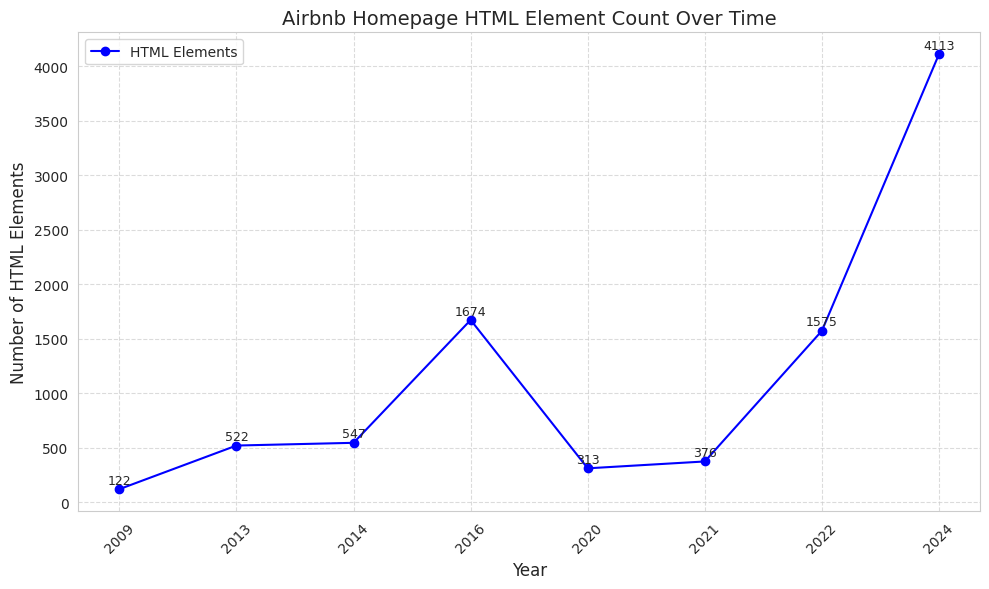

In [8]:
# Define base directories
BASE_DIR = "Airbnb_Website_Archive"
SNAPSHOTS_DIR = os.path.join(BASE_DIR, "Snapshots")
YEARS = ["2009", "2013", "2014", "2016", "2020", "2021", "2022", "2024"]

def count_all_html_elements(file_path):
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            soup = BeautifulSoup(file, "html.parser")
            return len(soup.find_all())
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return 0

def get_cleaned_html_path(year):
    return os.path.join(SNAPSHOTS_DIR, year, f"{year}_airbnb_cleaned.html")

def analyze_total_elements_over_time():
    element_counts = {}
    for year in YEARS:
        file_path = get_cleaned_html_path(year)
        if os.path.exists(file_path):
            count = count_all_html_elements(file_path)
            element_counts[year] = count
            print(f"Year {year}: {count} HTML elements")
        else:
            element_counts[year] = 0
            print(f"Year {year}: Cleaned HTML file not found")

    years_list = list(element_counts.keys())
    counts_list = list(element_counts.values())

    plt.figure(figsize=(10, 6))
    plt.plot(years_list, counts_list, marker='o', linestyle='-', color='b', label='HTML Elements')
    for i, count in enumerate(counts_list):
        plt.text(i, count + 50, str(count), ha='center', fontsize=9)

    plt.title('Airbnb Homepage HTML Element Count Over Time', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of HTML Elements', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

analyze_total_elements_over_time()

**SUMMARY TABLE OF KEY ELEMENT**

In [9]:
#Summary table
KEY_ELEMENTS = {
    "Structural": ["div", "section", "span", "p", "h1"],
    "Media": ["img", "svg"],
    "Interactive": ["a", "script", "button"],
}

def count_key_html_elements(file_path):
    element_counts = {element: 0 for category in KEY_ELEMENTS.values() for element in category}
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            soup = BeautifulSoup(file, "html.parser")
            for element in element_counts.keys():
                element_counts[element] = len(soup.find_all(element))
            total_elements = sum(element_counts.values())
            return element_counts, total_elements
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return {}, 0

def analyze_key_elements_over_time():
    """Analyze and display styled table of key HTML elements, return DataFrame."""
    element_summary = []
    for year in os.listdir(SNAPSHOTS_DIR):
        year_folder_path = os.path.join(SNAPSHOTS_DIR, year)
        if not os.path.isdir(year_folder_path):
            continue

        for file in os.listdir(year_folder_path):
            if file.endswith("_cleaned.html"):
                file_path = os.path.join(year_folder_path, file)
                element_counts, total_elements = count_key_html_elements(file_path)
                element_summary.append({
                    "Year": int(year),
                    **element_counts,
                    "Total Elements": total_elements,
                })

    summary_df = pd.DataFrame(element_summary).sort_values(by="Year")
    styled_df = summary_df.style \
        .set_properties(**{'border': '1px solid black', 'text-align': 'center', 'padding': '5px'}) \
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f7f7f7'), ('font-weight', 'bold')]}]) \
        .set_caption("HTML Key Element Counts Over Time") \
        .format({"Year": "{:d}"})

    display(styled_df)  # Display the styled table

    return summary_df

# Get the DataFrame
summary_df = analyze_key_elements_over_time()


,Year,div,section,span,p,h1,img,svg,a,script,button,Total Elements
6,2009,42,0,3,2,1,9,0,23,8,0,88
1,2013,79,0,18,8,1,14,0,120,12,6,258
4,2014,188,0,5,36,1,14,0,90,7,2,343
3,2016,521,0,491,99,12,2,21,167,8,6,1327
7,2020,122,5,25,0,0,2,13,53,8,2,230
2,2021,140,6,50,0,0,1,16,59,8,10,290
5,2022,788,4,674,0,1,0,9,26,6,10,1518
0,2024,1799,3,1397,0,0,82,72,260,0,62,3675


**Total Key HTML Elements Over Time**

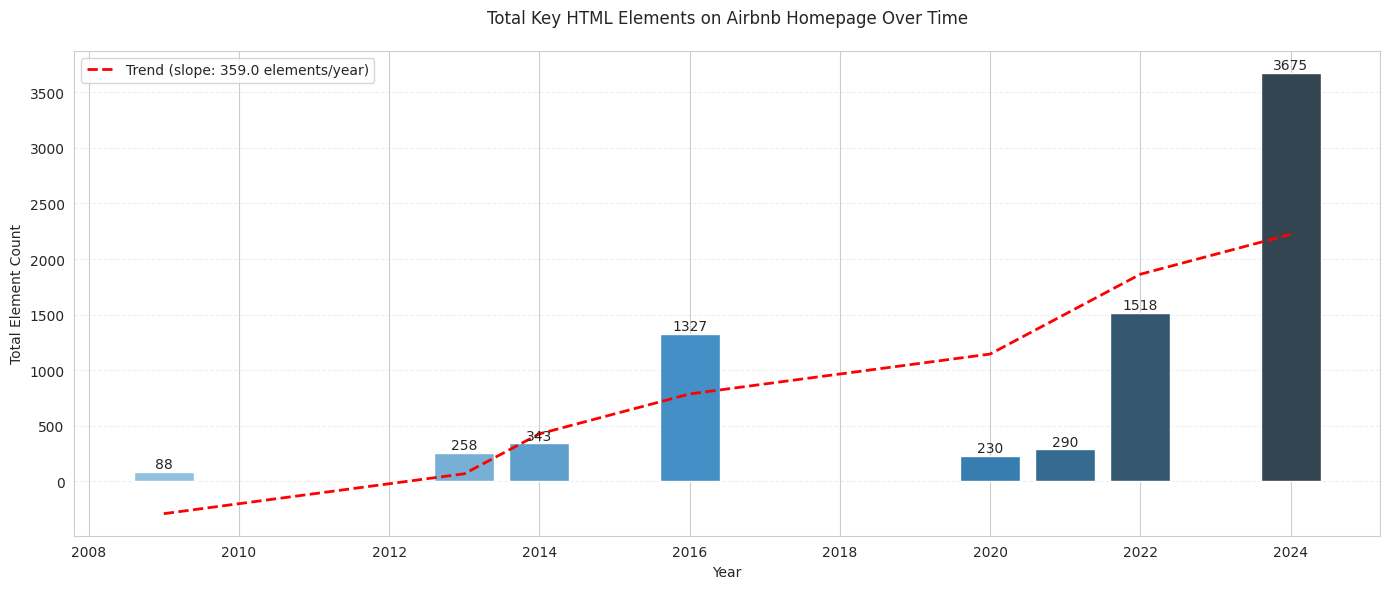

In [10]:
def plot_total_key_elements_bar(summary_df):
    plt.figure(figsize=(14, 6))
    summary_df = summary_df.sort_values(by="Year")

    bars = plt.bar(summary_df["Year"], summary_df["Total Elements"],
                   color=sns.color_palette("Blues_d", len(summary_df)))

    if len(summary_df) > 1:
        z = np.polyfit(range(len(summary_df["Year"])), summary_df["Total Elements"], 1)
        p = np.poly1d(z)
        plt.plot(summary_df["Year"], p(range(len(summary_df["Year"]))), "r--", linewidth=2,
                 label=f"Trend (slope: {z[0]:.1f} elements/year)")

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                 f'{int(height)}', ha='center', va='bottom', fontsize=10)

    plt.xlabel("Year")
    plt.ylabel("Total Element Count")
    plt.title("Total Key HTML Elements on Airbnb Homepage Over Time", pad=20)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3, axis='y')
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

plot_total_key_elements_bar(summary_df)  # Use the summary_df from Cell 2

**Structural HTML Element Counts Over Time**

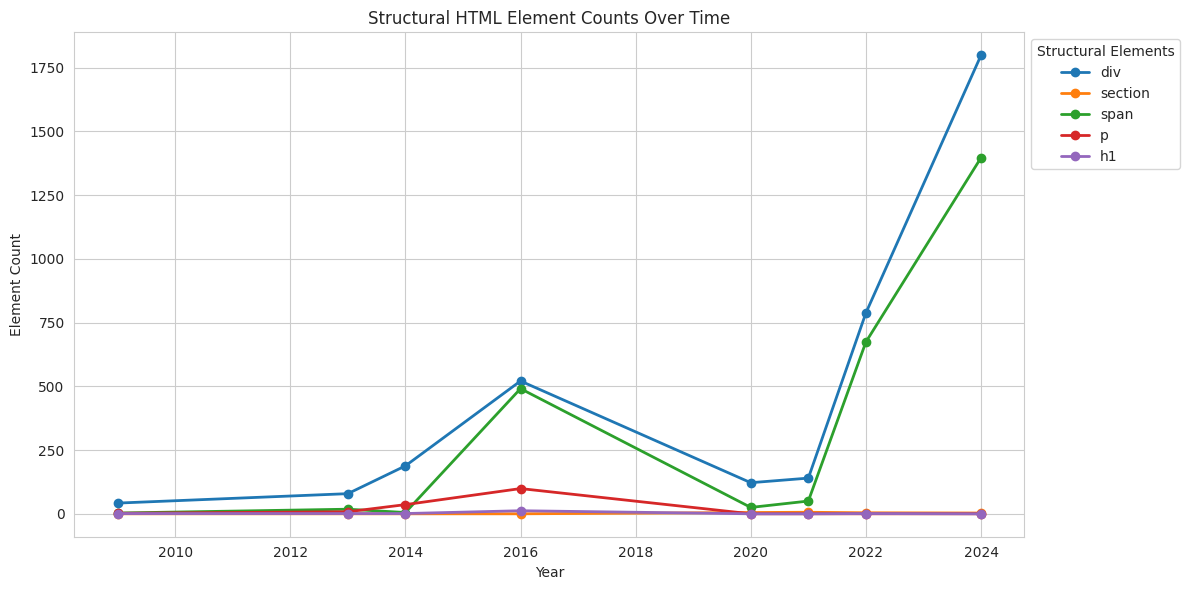

In [11]:
import matplotlib.pyplot as plt

def plot_structural_elements(df):
    # Define structural elements
    structural_elements = ["div", "section", "span", "p", "h1"]

    # Set the plot size
    plt.figure(figsize=(12, 6))

    # Plot each structural element with markers
    for element in structural_elements:
        plt.plot(df["Year"], df[element], label=element, marker='o', markersize=6, linestyle='-', linewidth=2)

    # Add labels and title
    plt.xlabel("Year")
    plt.ylabel("Element Count")
    plt.title("Structural HTML Element Counts Over Time")

    # Show legend
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1), title="Structural Elements")

    # Display grid
    plt.grid(True)

    # Display the plot
    plt.tight_layout()
    plt.show()

# Call the function to plot only structural elements
plot_structural_elements(summary_df)

**Correlation between HTML elements and Styling complexity**

   Year  div_count  span_count  css_js_count  style_count  class_count
0  2009         42           3             3           12           15
1  2013         79          18             5            7          198
2  2014        188           5             5           10          353
3  2016        521         491             5           52          927
4  2020        122          25             0           36          242
5  2021        140          50             1           31          298
6  2022        788         674             0          701         1124
7  2024       1799        1397             0          897         3181


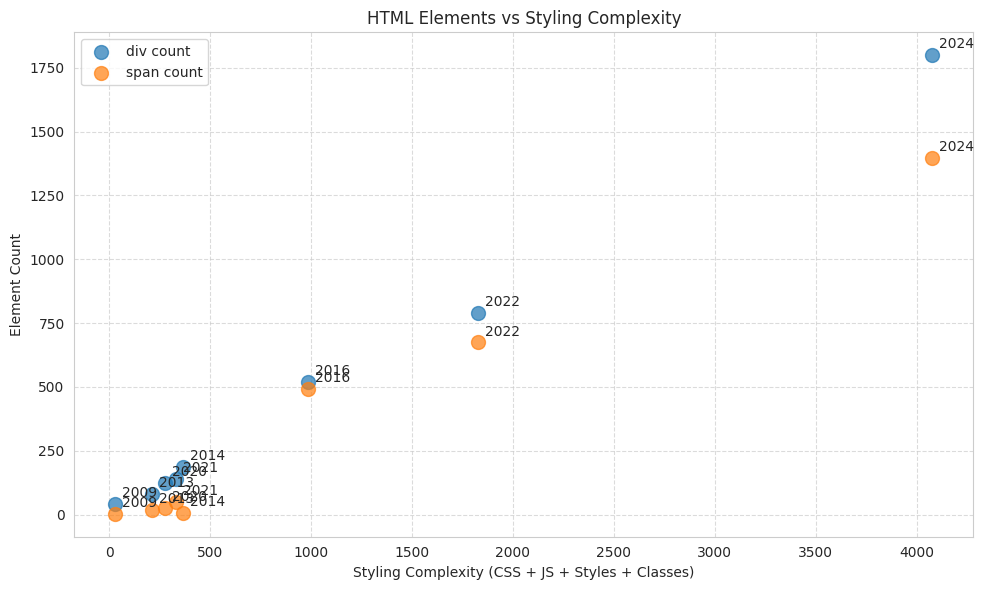

In [12]:
def analyze_html_for_dynamic_content(file_path):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as file:
        html_content = file.read()

    soup = BeautifulSoup(html_content, "html.parser")

    # Count structural elements
    div_count = len(soup.find_all("div"))
    span_count = len(soup.find_all("span"))

    # Count styling elements
    css_files = len(soup.find_all("link", rel="stylesheet"))
    js_files = len(soup.find_all("script", src=True))
    inline_styles = len(soup.find_all(style=True))
    style_tags = len(soup.find_all("style"))
    elements_with_class = len(soup.find_all(class_=True))

    return {
        "div_count": div_count,
        "span_count": span_count,
        "css_js_count": css_files + js_files,
        "style_count": inline_styles + style_tags,
        "class_count": elements_with_class
    }

# Analyze Airbnb HTML files
results = {}
base_dir = "Airbnb_Website_Archive/Snapshots"

for year_folder in sorted(os.listdir(base_dir)):
    year_folder_path = os.path.join(base_dir, year_folder)
    if os.path.isdir(year_folder_path):
        cleaned_file = os.path.join(year_folder_path, f"{year_folder}_airbnb_cleaned.html")
        if os.path.exists(cleaned_file):
            results[year_folder] = analyze_html_for_dynamic_content(cleaned_file)

# Convert to DataFrame and sort by year
df = pd.DataFrame.from_dict(results, orient='index')
df.index.name = 'Year'
df.reset_index(inplace=True)
df.sort_values('Year', inplace=True)

# Display table in the exact format requested
print(df.to_string(index=True))

# Create scatter plot showing correlation
plt.figure(figsize=(10, 6))

# Calculate styling complexity score
df['styling_complexity'] = df['css_js_count'] + df['style_count'] + df['class_count']

# Scatter plot with both div and span counts
plt.scatter(df['styling_complexity'], df['div_count'], s=100, alpha=0.7, label='div count')
plt.scatter(df['styling_complexity'], df['span_count'], s=100, alpha=0.7, label='span count')

# Add year labels to each point
for i, year in enumerate(df['Year']):
    plt.annotate(year, (df['styling_complexity'].iloc[i], df['div_count'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points')
    plt.annotate(year, (df['styling_complexity'].iloc[i], df['span_count'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points')

plt.xlabel('Styling Complexity (CSS + JS + Styles + Classes)')
plt.ylabel('Element Count')
plt.title('HTML Elements vs Styling Complexity')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Image and visual element changes**

+--------+------------------------+--------------+----------------------------+--------------------+--------------------+-----------------------+-----------------------+-------------------+
|  Year  | Traditional <img> Tags | SVG Elements | Explicit Background Images | CSS Style Elements | Atomic CSS Modules | Modern CSS Techniques | Total Visual Elements | Modern Elements % |
+--------+------------------------+--------------+----------------------------+--------------------+--------------------+-----------------------+-----------------------+-------------------+
| 2009.0 |          9.0           |     0.0      |            0.0             |        0.0         |        0.0         |          0.0          |          9.0          |        0.0        |
| 2013.0 |          14.0          |     0.0      |            0.0             |        0.0         |        0.0         |          0.0          |         14.0          |        0.0        |
| 2014.0 |          14.0          |     0.0      |

,Year,Traditional Tags,SVG Elements,Explicit Background Images,CSS Style Elements,Atomic CSS Modules,Modern CSS Techniques,Total Visual Elements,Modern Elements %
0,2009,9,0,0,0,0,0,9,0.0%
1,2013,14,0,0,0,0,0,14,0.0%
2,2014,14,0,8,12,0,1,28,50.0%
3,2016,2,21,0,15,0,3,30,95.0%
4,2020,2,13,4,5,0,5,22,88.6%
5,2021,1,16,0,1,0,5,18,91.7%
6,2022,0,9,0,240,315,8,224,99.8%
7,2024,82,72,40,280,3012,5,1238,93.3%


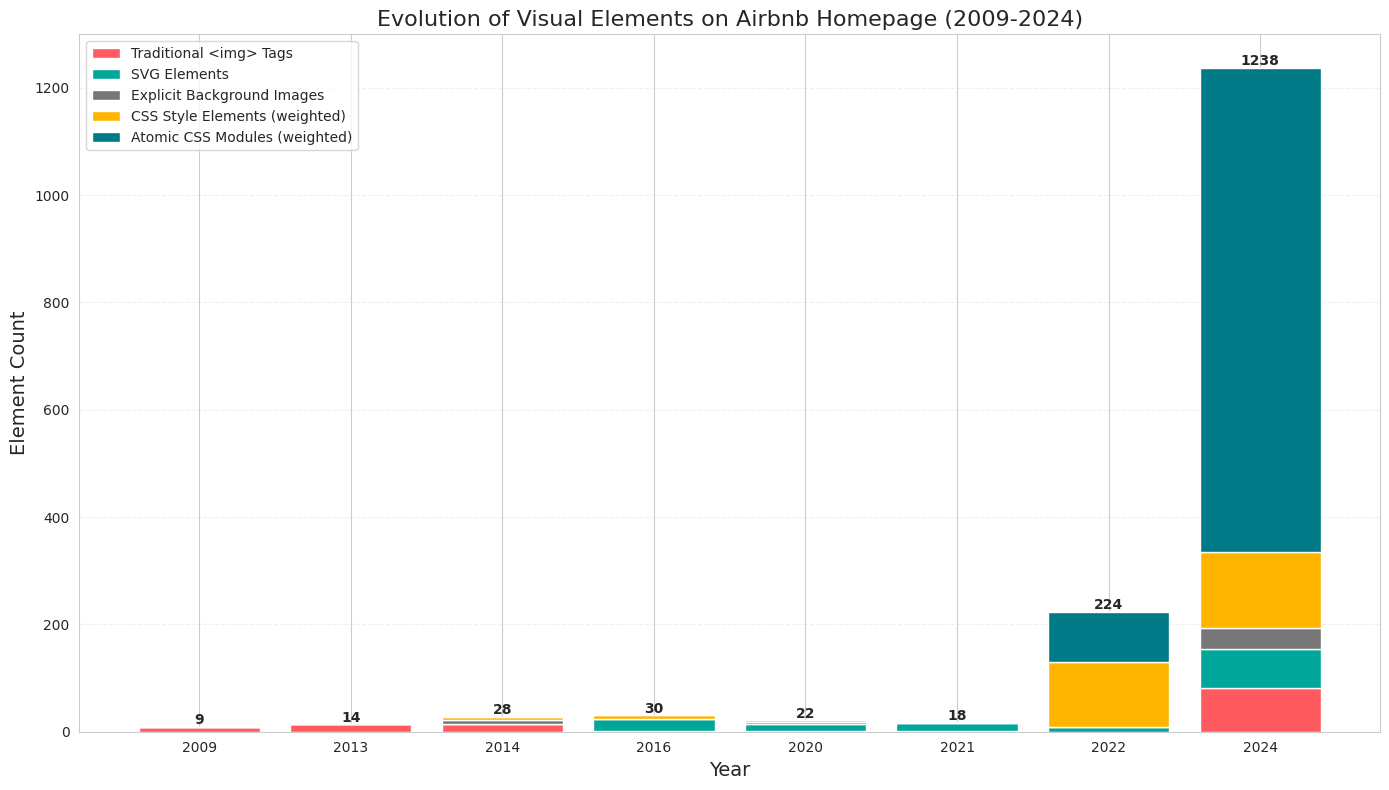

In [13]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import re
from tabulate import tabulate
from IPython.display import display

# Define base directories
BASE_DIR = "Airbnb_Website_Archive"
SNAPSHOTS_DIR = os.path.join(BASE_DIR, "Snapshots")
YEARS = ["2009", "2013", "2014", "2016", "2020", "2021", "2022", "2024"]

def get_cleaned_html_path(year):
    return os.path.join(SNAPSHOTS_DIR, year, f"{year}_airbnb_cleaned.html")

def count_image_elements(file_path):
    """Count different types of image elements in the HTML with enhanced CSS class detection"""
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            content = file.read()
            soup = BeautifulSoup(content, "html.parser")

            # Count traditional <img> tags
            img_tags = len(soup.find_all('img'))

            # Count SVG elements
            svg_elements = len(soup.find_all('svg'))

            # Count explicit CSS background images
            explicit_bg_images = len(re.findall(r'background-image:\s*url\(["\']?([^"\']*)["\']?\)', content))

            # Count CSS classes that might be used for background images
            bg_classes = 0

            # Count classes with background-related keywords
            bg_classes += len(re.findall(r'class=["\']([^"\']*background[^"\']*)["\']', content))

            # Count style attributes with background-related properties
            bg_classes += len(re.findall(r'style=["\'][^"\']*background[^"\']*["\']', content))

            # Count modern Airbnb-specific class patterns (2022+)
            airbnb_bg_classes = len(re.findall(r'class=["\'](.*?atm_.*?)["\']', content))

            # Count div elements that might contain images
            div_elements = len(soup.find_all('div'))

            return {
                'img_tags': img_tags,
                'svg_elements': svg_elements,
                'explicit_bg_images': explicit_bg_images,
                'css_style_images': bg_classes,
                'atomic_css_modules': airbnb_bg_classes,
                'div_elements': div_elements,
                'total_visual_elements': img_tags + svg_elements + explicit_bg_images +
                                         (bg_classes * 0.5) + (airbnb_bg_classes * 0.3)
            }
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return {
            'img_tags': 0,
            'svg_elements': 0,
            'explicit_bg_images': 0,
            'css_style_images': 0,
            'atomic_css_modules': 0,
            'div_elements': 0,
            'total_visual_elements': 0
        }

def analyze_css_techniques(file_path):
    """Analyze CSS techniques used for image display"""
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            content = file.read()

            # Check for modern CSS techniques
            has_background_size = bool(re.search(r'background-size', content))
            has_background_position = bool(re.search(r'background-position', content))
            has_css_transitions = bool(re.search(r'transition', content))
            has_css_transforms = bool(re.search(r'transform', content))
            has_css_filters = bool(re.search(r'filter:', content))
            has_mask_image = bool(re.search(r'mask-image|webkit-mask-image', content))
            has_object_fit = bool(re.search(r'object-fit', content))
            has_modern_classes = bool(re.search(r'atm_|class=["\']\w+\[class\]', content))

            return {
                'modern_techniques_count': sum([
                    has_background_size, has_background_position, has_css_transitions,
                    has_css_transforms, has_css_filters, has_mask_image, has_object_fit,
                    has_modern_classes
                ])
            }
    except Exception as e:
        print(f"Error analyzing CSS in {file_path}: {e}")
        return {
            'modern_techniques_count': 0
        }

def analyze_image_elements_over_time():
    """Analyze image-related elements over the years"""
    results = {}
    css_techniques = {}

    for year in YEARS:
        file_path = get_cleaned_html_path(year)
        if os.path.exists(file_path):
            counts = count_image_elements(file_path)
            css_tech = analyze_css_techniques(file_path)

            results[year] = counts
            css_techniques[year] = css_tech
        else:
            results[year] = {
                'img_tags': 0,
                'svg_elements': 0,
                'explicit_bg_images': 0,
                'css_style_images': 0,
                'atomic_css_modules': 0,
                'div_elements': 0,
                'total_visual_elements': 0
            }
            css_techniques[year] = {
                'modern_techniques_count': 0
            }
            print(f"Year {year}: Cleaned HTML file not found")

    return results, css_techniques

def create_summary_table(results, css_techniques):
    """Create a summary table of visual elements and CSS techniques"""
    # Create a DataFrame for the summary table
    summary_data = []

    for year in YEARS:
        if year in results:
            row = {
                'Year': int(year),  # Convert to integer for better formatting
                'Traditional <img> Tags': results[year]['img_tags'],
                'SVG Elements': results[year]['svg_elements'],
                'Explicit Background Images': results[year]['explicit_bg_images'],
                'CSS Style Elements': results[year]['css_style_images'],
                'Atomic CSS Modules': results[year]['atomic_css_modules'],
                'Modern CSS Techniques': css_techniques[year]['modern_techniques_count'],
                'Total Visual Elements': round(results[year]['total_visual_elements'])
            }
            summary_data.append(row)

    df = pd.DataFrame(summary_data)

    # Calculate the percentage of modern vs traditional elements
    df['Modern Elements %'] = ((df['SVG Elements'] + df['Explicit Background Images'] +
                              df['CSS Style Elements'] * 0.5 + df['Atomic CSS Modules'] * 0.3) /
                             df['Total Visual Elements'] * 100).round(1)

    # Replace NaN with 0
    df = df.fillna(0)

    # Create a nicely formatted table using tabulate
    print(tabulate(df, headers='keys', tablefmt='pretty', showindex=False))

    # Create a styled version of the table for Jupyter notebooks
    styled_df = df.style \
        .set_properties(**{'border': '1px solid black', 'text-align': 'center', 'padding': '5px'}) \
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f7f7f7'), ('font-weight', 'bold')]}]) \
        .set_caption("HTML Key Element Counts Over Time (2009-2024)") \
        .format({"Modern Elements %": "{:.1f}%"}) \
        .background_gradient(cmap='YlOrRd', subset=['Modern Elements %', 'Total Visual Elements'])

    try:
        display(styled_df)  # Explicitly display the styled table
    except:
        # If display function is not available (e.g., not in Jupyter), use alternative
        print("\nStylized table not displayed - requires Jupyter notebook environment")

    return df

def create_stacked_visual_elements_chart(results):
    """Create a stacked bar chart showing the composition of visual elements"""
    df = pd.DataFrame(results).T

    # Create a stacked bar chart
    fig, ax = plt.subplots(figsize=(14, 8))

    # Create the stacked bars
    bottom_vals = np.zeros(len(df))

    # Traditional <img> tags (bottom layer)
    img_bars = ax.bar(df.index, df['img_tags'], label='Traditional <img> Tags', color='#FF5A5F')

    # SVG elements (next layer)
    bottom_vals += df['img_tags']
    svg_bars = ax.bar(df.index, df['svg_elements'], bottom=bottom_vals, label='SVG Elements', color='#00A699')

    # Explicit background images (next layer)
    bottom_vals += df['svg_elements']
    bg_bars = ax.bar(df.index, df['explicit_bg_images'], bottom=bottom_vals, label='Explicit Background Images', color='#767676')

    # CSS Style Elements (next layer) - weighted by 0.5 for visualization
    bottom_vals += df['explicit_bg_images']
    bg_class_bars = ax.bar(df.index, df['css_style_images']*0.5, bottom=bottom_vals, label='CSS Style Elements (weighted)', color='#FFB400')

    # Atomic CSS Modules (top layer) - weighted by 0.3 for visualization
    bottom_vals += df['css_style_images']*0.5
    modern_bars = ax.bar(df.index, df['atomic_css_modules']*0.3, bottom=bottom_vals, label='Atomic CSS Modules (weighted)', color='#007A87')

    # Add title and labels
    ax.set_title('Evolution of Visual Elements on Airbnb Homepage (2009-2024)', fontsize=16)
    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('Element Count', fontsize=14)

    # Add legend
    ax.legend(loc='upper left')

    # Add grid
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')

    # Add data labels on top of each bar
    for i, year in enumerate(df.index):
        total = df.loc[year, 'total_visual_elements']
        ax.text(i, total + 5, f'{round(total)}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run the analysis
results, css_techniques = analyze_image_elements_over_time()

# Generate and display summary table
summary_df = create_summary_table(results, css_techniques)

# Generate and display stacked bar chart
create_stacked_visual_elements_chart(results)

**Interactive Element Visualization**

In [14]:
summary_df = analyze_key_elements_over_time()

,Year,div,section,span,p,h1,img,svg,a,script,button,Total Elements
6,2009,42,0,3,2,1,9,0,23,8,0,88
1,2013,79,0,18,8,1,14,0,120,12,6,258
4,2014,188,0,5,36,1,14,0,90,7,2,343
3,2016,521,0,491,99,12,2,21,167,8,6,1327
7,2020,122,5,25,0,0,2,13,53,8,2,230
2,2021,140,6,50,0,0,1,16,59,8,10,290
5,2022,788,4,674,0,1,0,9,26,6,10,1518
0,2024,1799,3,1397,0,0,82,72,260,0,62,3675


Year,2009,2013,2014,2016,2020,2021,2022,2024
a,23,120,90,167,53,59,26,260
script,8,12,7,8,8,8,6,0
button,0,6,2,6,2,10,10,62


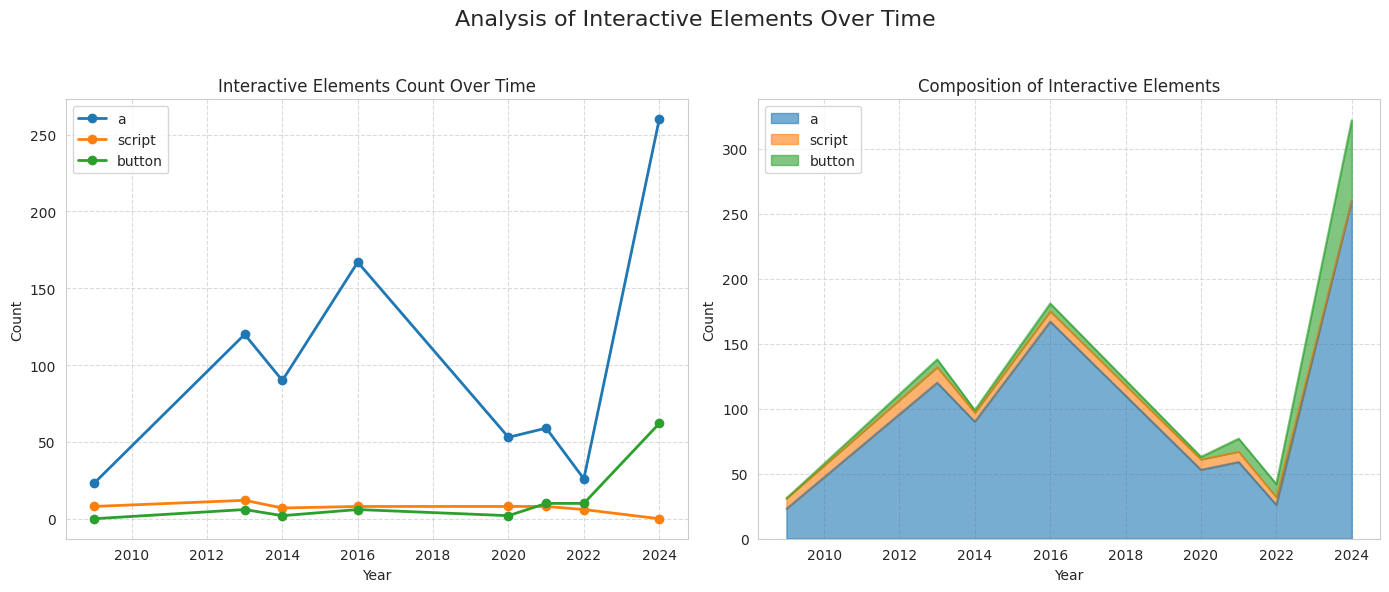

In [15]:
def create_interactive_elements_plots(summary_df):
    """
    Create plots and a horizontal summary table to visualize interactive elements from HTML analysis

    Args:
        summary_df: DataFrame containing the HTML element counts by year
    """
    if summary_df is None or summary_df.empty:
        print("Error: No data available for plotting")
        return None

    df = summary_df.copy()

    # Define interactive elements
    interactive_elements = ['a', 'script', 'button']

    # Make sure these columns exist in the DataFrame
    available_elements = [col for col in interactive_elements if col in df.columns]

    if not available_elements:
        print("Error: None of the required interactive elements found in DataFrame")
        return None

    # Filter DataFrame to include only Year and available interactive elements
    interactive_df = df[['Year'] + available_elements].copy()

    # Ensure numeric data types
    for col in available_elements:
        interactive_df[col] = pd.to_numeric(interactive_df[col], errors='coerce').fillna(0).astype(int)

    # Create and display styled summary table
    # Transpose the DataFrame for the horizontal table (Years as columns, elements as rows)
    table_df = interactive_df.set_index('Year').T

    # Display styled table
    styled_table = table_df.style \
        .set_properties(**{'border': '1px solid black', 'text-align': 'center', 'padding': '5px'}) \
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f7f7f7'), ('font-weight', 'bold')]}]) \
        .set_caption("Interactive Elements Counts Over Time") \
        .format("{:.0f}")  # Format numbers as integers

    display(styled_table)

    # Create a figure with two subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Analysis of Interactive Elements Over Time', fontsize=16)

    # 1. Line plot for interactive elements over time
    ax1 = axes[0]
    for element in available_elements:
        ax1.plot(interactive_df['Year'], interactive_df[element], marker='o', linewidth=2, label=element)

    ax1.set_xlabel('Year')
    ax1.set_ylabel('Count')
    ax1.set_title('Interactive Elements Count Over Time')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # 2. Stacked area chart for interactive elements
    ax2 = axes[1]
    plot_df = interactive_df.set_index('Year')[available_elements]

    # Create stacked area plot
    plot_df.plot.area(alpha=0.6, ax=ax2)

    ax2.set_xlabel('Year')
    ax2.set_ylabel('Count')
    ax2.set_title('Composition of Interactive Elements')
    ax2.grid(True, linestyle='--', alpha=0.7)

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    return fig

plot_fig = create_interactive_elements_plots(summary_df)
plt.show()